# NZ Road Crash ML - EDA

## Load Libraries and Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Set Seaborn theme and context for better aesthetics
sns.set_theme(style="white")
sns.set_context("notebook", font_scale=1.1)
sns.despine()
%config InlineBackend.figure_format = 'retina'

<Figure size 640x480 with 0 Axes>

In [4]:
df = pd.read_csv('data/Crash_Analysis_System__CAS__data.csv')
df.head()

,X,Y,OBJECTID,advisorySpeed,areaUnitID,bicycle,bridge,bus,carStationWagon,cliffBank,...,train,tree,truck,unknownVehicleType,urban,vanOrUtility,vehicle,waterRiver,weatherA,weatherB
0,1747565.0,5427642.0,1,NaN,575300.0,0.0,NaN,0.0,2.0,NaN,...,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
1,1544693.0,5170620.0,2,NaN,587020.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,Open,0.0,0.0,0.0,Fine,Null
2,1615685.0,5423963.0,3,NaN,584201.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,Urban,0.0,0.0,0.0,Fine,Null
3,1799588.0,5821916.0,4,NaN,527007.0,0.0,NaN,0.0,2.0,NaN,...,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null
4,1570549.0,5176071.0,5,NaN,591101.0,1.0,NaN,0.0,0.0,NaN,...,NaN,NaN,0.0,0.0,Urban,0.0,NaN,NaN,Fine,Null


## Inspect the target

In [5]:
df['crashSeverity'].value_counts(normalize=True).round(2)*100

crashSeverity
Non-Injury Crash    70.0
Minor Crash         23.0
Serious Crash        6.0
Fatal Crash          1.0
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Distribution of Crash Severity')

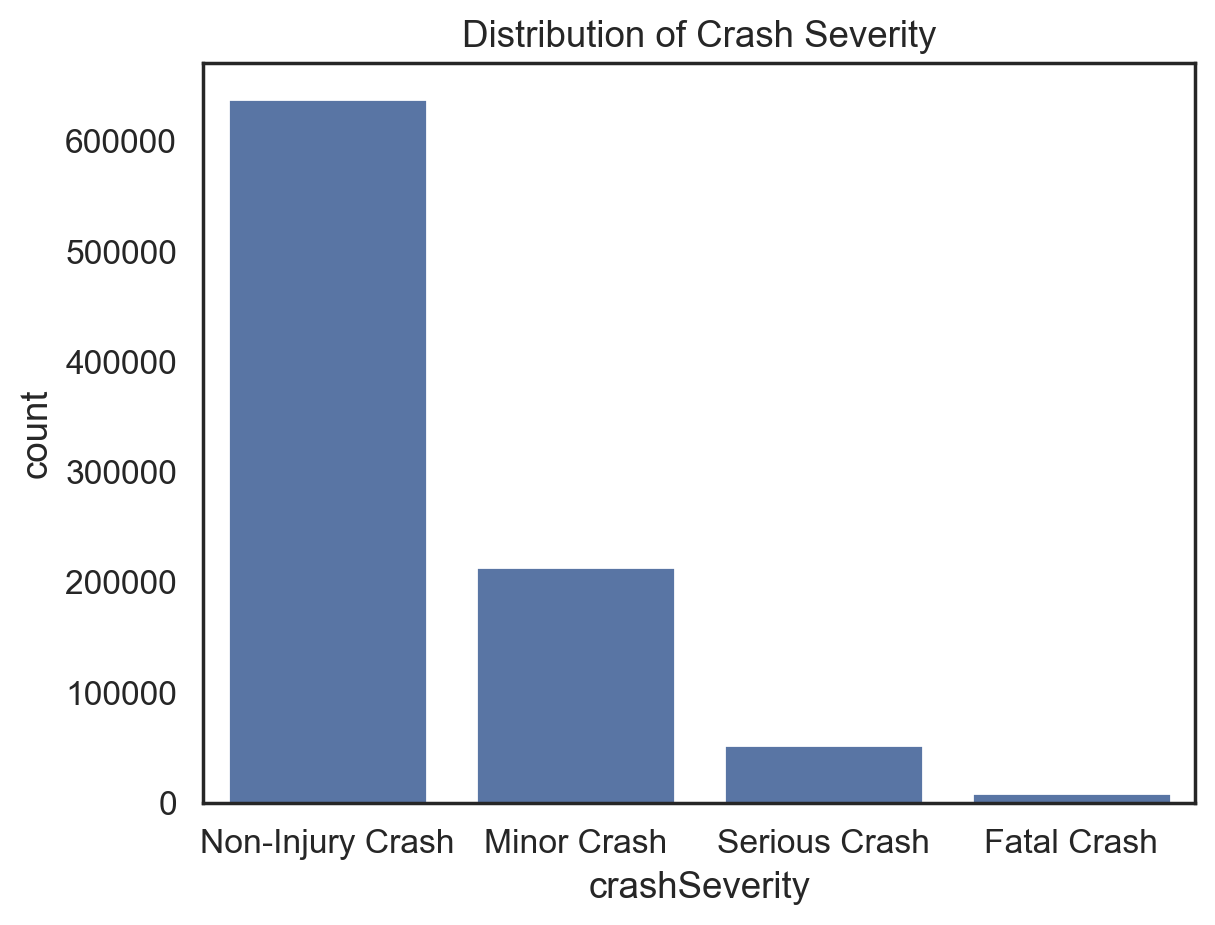

In [6]:
sns.countplot(x='crashSeverity', data=df, order=df['crashSeverity'].value_counts().index)
plt.title('Distribution of Crash Severity')

As we can see our target suffers from class imbalance with Fatal Crash only being 1% of the whole dataset. The majority class being Non-Injury Crash with 69% of the total crashes. 
It is importance to note that a baseline model which always predicts a crash being Non-Injury will have an average of 69% accuracy. 
So there are key considerations when building the classifier model: 
- The evaluation metric used to deal with class imbalance.
- Comparision with the baseline model.
- Techniques to deal with class imbalance: class weighting, resampling, or class-conditional thresholds.

## Inspect the features

### Remove Unnecessary Features

In [7]:
df.columns

Index(['X', 'Y', 'OBJECTID', 'advisorySpeed', 'areaUnitID', 'bicycle',
       'bridge', 'bus', 'carStationWagon', 'cliffBank',
       'crashDirectionDescription', 'crashFinancialYear', 'crashLocation1',
       'crashLocation2', 'crashRoadSideRoad', 'crashSeverity',
       'crashSHDescription', 'crashYear', 'debris', 'directionRoleDescription',
       'ditch', 'fatalCount', 'fence', 'flatHill', 'guardRail', 'holiday',
       'houseOrBuilding', 'intersection', 'kerb', 'light', 'meshblockId',
       'minorInjuryCount', 'moped', 'motorcycle', 'NumberOfLanes',
       'objectThrownOrDropped', 'otherObject', 'otherVehicleType', 'overBank',
       'parkedVehicle', 'pedestrian', 'phoneBoxEtc', 'postOrPole', 'region',
       'roadCharacter', 'roadLane', 'roadSurface', 'roadworks', 'schoolBus',
       'seriousInjuryCount', 'slipOrFlood', 'speedLimit', 'strayAnimal',
       'streetLight', 'suv', 'taxi', 'temporarySpeedLimit', 'tlaId', 'tlaName',
       'trafficControl', 'trafficIsland', 'trafficSi

Strategies to select features for the model:
- Remove features that are too sparse. (>90% null)
- Remove features that will lead to target leakage. (unknow at the time of prediction or direct indicate of target)
- Remove identifier and free text (IDs, X, Y coordinate, locations (street))

In [8]:
missing_count = df.isnull().sum().sort_values(ascending=False).to_frame(name='missing_count')
missing_count['missing_percentage'] = (missing_count['missing_count'] / len(df) * 100).round(2)
missing_count[missing_count['missing_percentage'] > 90]

,missing_count,missing_percentage
intersection,913464,100.00
crashRoadSideRoad,913464,100.00
temporarySpeedLimit,897788,98.28
pedestrian,883236,96.69
advisorySpeed,877345,96.05
holiday,863013,94.48


In [9]:
df['holiday'].value_counts()

holiday
Christmas New Year    23447
Easter                10408
Queens Birthday        8722
Labour Weekend         7874
Name: count, dtype: int64

Based on the missing percentage we will drop `intersection`, `crashRoadSideRoad`, `temporarySpeedLimit`, `pedestrian`, `advisorySpeed` as they have > 90% Nulls. In the case of `holiday` after checking on the field description we learned that Nulls indicates it's a normal day. So we will impute with 'Normal Day' and use that as a feature.

In [10]:
df.drop(columns=missing_count.head(5).index, inplace=True)

In [11]:
df['holiday'] = df['holiday'].fillna('Normal Day')

In [12]:
df['holiday'].value_counts(normalize=True).round(2)*100

holiday
Normal Day            94.0
Christmas New Year     3.0
Easter                 1.0
Queens Birthday        1.0
Labour Weekend         1.0
Name: proportion, dtype: float64

Now we will drop the features that lead to target leakage.

In [13]:
columns_to_drop =df.filter(regex='.*Count$').columns
columns_to_drop

Index(['fatalCount', 'minorInjuryCount', 'seriousInjuryCount'], dtype='str')

In [14]:
df.drop(columns=columns_to_drop, inplace=True)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913464 entries, 0 to 913463
Data columns (total 64 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   X                          913464 non-null  float64
 1   Y                          913464 non-null  float64
 2   OBJECTID                   913464 non-null  int64  
 3   areaUnitID                 913460 non-null  float64
 4   bicycle                    913459 non-null  float64
 5   bridge                     376691 non-null  float64
 6   bus                        913459 non-null  float64
 7   carStationWagon            913459 non-null  float64
 8   cliffBank                  376691 non-null  float64
 9   crashDirectionDescription  913464 non-null  str    
 10  crashFinancialYear         913464 non-null  str    
 11  crashLocation1             913464 non-null  str    
 12  crashLocation2             911557 non-null  str    
 13  crashSeverity              913464 non-nu

In [16]:
columns_to_drop = df.columns[df.columns.str.lower().str.endswith('id')]
columns_to_drop

Index(['OBJECTID', 'areaUnitID', 'meshblockId', 'tlaId'], dtype='str')

In [17]:
df.drop(columns=columns_to_drop, inplace=True)

In [18]:
df.drop(columns=['X', 'Y', 'crashLocation1', 'crashLocation2', 'crashFinancialYear'], inplace=True)

Now that we have 55 columns left.
We will also remove `tlaName` (67 distinct values) as we have `region` is a less cardinarity feature.

In [19]:
df.drop('tlaName', axis=1, inplace=True)

### Null Values Imputation and Features Size Reduction

In [20]:
df.isna().sum().sort_values(ascending=False).head(23)

bridge                   536773
cliffBank                536773
guardRail                536773
fence                    536773
ditch                    536773
debris                   536773
houseOrBuilding          536773
kerb                     536773
tree                     536773
trafficIsland            536773
vehicle                  536773
waterRiver               536773
trafficSign              536773
strayAnimal              536773
roadworks                536773
slipOrFlood              536773
phoneBoxEtc              536773
postOrPole               536773
parkedVehicle            536773
overBank                 536773
otherObject              536773
objectThrownOrDropped    536773
train                    536773
dtype: int64

The variables that contain the same number of null values could due to these variables are not recorded in earlier time. Let verify our assumption.

In [21]:
df[df['bridge'].isna()]['crashYear'].value_counts().sort_index()

crashYear
2000    20951
2001    23374
2002    24382
2003    24041
2004    22886
2005    23447
2006    23894
2007    24862
2008    23718
2009    23011
2010    22461
2011    19780
2012    18619
2013    18642
2014    18369
2015    19773
2016    21819
2017    22314
2018    21653
2019    20458
2020    16791
2021    17490
2022    15572
2023    16197
2024    15412
2025    15397
2026     1460
Name: count, dtype: int64

The NULL values spread evenly across years so our assumption is not right. Our assumption leads to the NULLs appear together could because: when a crash has no "objects struck" record (i.e., it was a pure vehicle-to-vehicle collision with no roadside object hit), all these fields are absent simultaneously. The 536,773 missing rows are structurally the same set of records.

Keeping this assumption in mind, since NaN means "no object struck" (structural absence from the source table), we can collapse all 23 object-struck indicators into a single binary feature and drop the originals.

In [22]:
object_struck_cols = [
    'bridge', 'cliffBank', 'guardRail', 'fence', 'ditch', 'debris',
    'houseOrBuilding', 'kerb', 'tree', 'trafficIsland', 'vehicle',
    'waterRiver', 'trafficSign', 'strayAnimal', 'roadworks', 'slipOrFlood',
    'phoneBoxEtc', 'postOrPole', 'parkedVehicle', 'overBank', 'otherObject',
    'objectThrownOrDropped', 'train'
]

df['objectStruck'] = (df[object_struck_cols].fillna(0).any(axis=1)).astype(int)
df.drop(columns=object_struck_cols, inplace=True)

print(df['objectStruck'].value_counts())
print(f"\nRemaining columns: {df.shape[1]}")

objectStruck
0    544807
1    368657
Name: count, dtype: int64

Remaining columns: 32


Similarly, collapse all per-vehicle-type count columns into a single `vehiclesInvolved` count and drop the originals.


In [23]:
vehicle_cols = [
    'bicycle', 'bus', 'carStationWagon', 'moped', 'motorcycle',
    'otherVehicleType', 'schoolBus', 'suv', 'taxi', 'truck',
    'unknownVehicleType', 'vanOrUtility'
]

df['vehiclesInvolved'] = df[vehicle_cols].fillna(0).sum(axis=1).astype(int)
df.drop(columns=vehicle_cols, inplace=True)

print(df['vehiclesInvolved'].value_counts().sort_index())
print(f"\nRemaining columns: {df.shape[1]}")


vehiclesInvolved
0        929
1     304192
2     528834
3      63898
4      12246
5       2472
6        600
7        181
8         61
9         28
10        10
11         7
12         3
15         2
17         1
Name: count, dtype: int64

Remaining columns: 21


Now that we only have 21 columns remaining. Is a much more manageble set of features.

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913464 entries, 0 to 913463
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   crashDirectionDescription  913464 non-null  str    
 1   crashSeverity              913464 non-null  str    
 2   crashSHDescription         913461 non-null  str    
 3   crashYear                  913464 non-null  int64  
 4   directionRoleDescription   913391 non-null  str    
 5   flatHill                   913464 non-null  str    
 6   holiday                    913464 non-null  str    
 7   light                      913464 non-null  str    
 8   NumberOfLanes              911196 non-null  float64
 9   region                     909990 non-null  str    
 10  roadCharacter              913464 non-null  str    
 11  roadLane                   913464 non-null  str    
 12  roadSurface                913464 non-null  str    
 13  speedLimit                 912043 non-nu

In [25]:
df[(df['weatherA'] == 'Null') & (df['weatherB'] != 'Null')][['weatherA', 'weatherB']]

,weatherA,weatherB
1016,Null,Frost
3807,Null,Strong wind
5887,Null,Frost
6954,Null,Frost
7806,Null,Frost
...,...,...
912044,Null,NaN
912314,Null,NaN
912613,Null,NaN
913030,Null,NaN


Merge `weatherB` into `weatherA`: where `weatherA` is `"Null"` and `weatherB` has a real value, impute with `weatherB`, then drop `weatherB`.


In [26]:
mask = (df['weatherA'] == 'Null') & (df['weatherB'].notna()) & (df['weatherB'] != 'Null')
df.loc[mask, 'weatherA'] = df.loc[mask, 'weatherB']
df.drop(columns=['weatherB'], inplace=True)

print(df['weatherA'].value_counts())

weatherA
Fine             707087
Light rain       138154
Heavy rain        36272
Null              16711
Mist or Fog       12785
Snow               1583
Frost               442
Strong wind         216
Hail or Sleet       214
Name: count, dtype: int64


We will impute Null values for `streetLight`, `region` as 'Unknown'

In [27]:
df.loc[df['streetLight'].isna() | (df['streetLight'] == 'Null'), 'streetLight'] = 'Unknown'
df.loc[df['region'].isna(), 'region'] = 'Unknown'

We will impute `NumberOfLanes`, `speedLimit`, `directionRoleDescription` and `crashSHDescription` with the Mode of each variable.

In [28]:
df.loc[df['NumberOfLanes'].isna(), 'NumberOfLanes'] = df['NumberOfLanes'].mode()[0]
df.loc[df['speedLimit'].isna(), 'speedLimit'] = df['speedLimit'].mode()[0]
df.loc[df['directionRoleDescription'].isna(), 'directionRoleDescription'] = df['directionRoleDescription'].mode()[0]
df.loc[df['crashSHDescription'].isna(), 'crashSHDescription'] = df['crashSHDescription'].mode()[0]


One thing to note is that there are some values in the `speedLimit` column appear to be strange as there are values for speedLimit of 51, 61, 6, 2 whihc is very unusual on New Zealand road. Luckily those values only appear on a handful of records in the dataset.

In [29]:
df['speedLimit'].value_counts()

speedLimit
50.0     543270
100.0    250261
80.0      48192
60.0      27508
70.0      27136
30.0       9844
40.0       2916
20.0       2037
10.0        941
110.0       703
90.0        627
5.0          16
15.0          9
61.0          1
6.0           1
2.0           1
51.0          1
Name: count, dtype: int64

In [30]:
df[df['speedLimit'].isin([51, 2, 6, 61, 5, 15])].head()

,crashDirectionDescription,crashSeverity,crashSHDescription,crashYear,directionRoleDescription,flatHill,holiday,light,NumberOfLanes,region,roadCharacter,roadLane,roadSurface,speedLimit,streetLight,trafficControl,urban,weatherA,objectStruck,vehiclesInvolved
470674,South,Minor Crash,No,2016,North,Flat,Normal Day,Overcast,2.0,Auckland Region,Nil,Off road,Sealed,15.0,Unknown,Nil,Urban,Heavy rain,0,2
509525,East,Non-Injury Crash,Yes,2015,North,Flat,Normal Day,Bright sun,1.0,Wellington Region,Nil,Off road,Sealed,5.0,Unknown,Nil,Urban,Fine,0,2
511554,East,Minor Crash,No,2015,South,Flat,Normal Day,Twilight,0.0,Auckland Region,Nil,Off road,Sealed,15.0,On,Nil,Urban,Fine,1,1
523703,South,Minor Crash,No,2016,North,Flat,Christmas New Year,Overcast,0.0,Wellington Region,Nil,Off road,Sealed,15.0,Unknown,Unknown,Urban,Light rain,0,2
529957,South,Minor Crash,No,2016,East,Null,Normal Day,Bright sun,2.0,Manawatū-Whanganui Region,Nil,Off road,Sealed,15.0,Unknown,Unknown,Urban,Null,0,2


Since they are all in urban area we will change them to 50.

In [31]:
df.loc[df['speedLimit'].isin([51, 2, 6, 61, 5, 15]), 'speedLimit'] = 50

In [32]:
df['speedLimit'].value_counts()

speedLimit
50.0     543299
100.0    250261
80.0      48192
60.0      27508
70.0      27136
30.0       9844
40.0       2916
20.0       2037
10.0        941
110.0       703
90.0        627
Name: count, dtype: int64

In [33]:
df.isna().sum().sort_values(ascending=False).head(10)

crashDirectionDescription    0
crashSeverity                0
crashSHDescription           0
crashYear                    0
directionRoleDescription     0
flatHill                     0
holiday                      0
light                        0
NumberOfLanes                0
region                       0
dtype: int64

There are no more Null in the dataset. Let's move the target to the back for easier convention.

In [34]:
col_list = df.columns.to_list()
col_list.remove('crashSeverity')
col_list.append('crashSeverity')
col_list

['crashDirectionDescription',
 'crashSHDescription',
 'crashYear',
 'directionRoleDescription',
 'flatHill',
 'holiday',
 'light',
 'NumberOfLanes',
 'region',
 'roadCharacter',
 'roadLane',
 'roadSurface',
 'speedLimit',
 'streetLight',
 'trafficControl',
 'urban',
 'weatherA',
 'objectStruck',
 'vehiclesInvolved',
 'crashSeverity']

In [35]:
df[col_list].head()

,crashDirectionDescription,crashSHDescription,crashYear,directionRoleDescription,flatHill,holiday,light,NumberOfLanes,region,roadCharacter,roadLane,roadSurface,speedLimit,streetLight,trafficControl,urban,weatherA,objectStruck,vehiclesInvolved,crashSeverity
0,South,No,2007,East,Flat,Normal Day,Overcast,2.0,Wellington Region,Nil,2-way,Sealed,50.0,Unknown,Nil,Urban,Fine,0,2,Non-Injury Crash
1,West,Yes,2008,West,Flat,Normal Day,Bright sun,2.0,Canterbury Region,Nil,2-way,Sealed,100.0,Unknown,Stop,Open,Fine,1,1,Non-Injury Crash
2,West,No,2008,North,Flat,Normal Day,Dark,2.0,Tasman Region,Nil,2-way,Sealed,50.0,On,Nil,Urban,Fine,1,1,Minor Crash
3,Null,No,2008,East,Flat,Normal Day,Overcast,2.0,Waikato Region,Nil,2-way,Sealed,50.0,Unknown,Give way,Urban,Fine,0,2,Minor Crash
4,West,No,2008,West,Flat,Normal Day,Bright sun,2.0,Canterbury Region,Nil,2-way,Sealed,50.0,Unknown,Unknown,Urban,Fine,0,2,Minor Crash


## Explore The Relationships

In [36]:
df = df[col_list]

severity_order = ['Non-Injury Crash', 'Minor Crash', 'Serious Crash', 'Fatal Crash']
severity_palette = {
    'Non-Injury Crash': '#2ecc71',
    'Minor Crash':      '#f1c40f',
    'Serious Crash':    '#e67e22',
    'Fatal Crash':      '#c0392b',
}
df['crashSeverity'] = pd.Categorical(df['crashSeverity'], categories=severity_order, ordered=True)

### Numerical Features vs Crash Severity

C:\Users\truon\AppData\Local\Temp\ipykernel_44404\3820487194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\truon\AppData\Local\Temp\ipykernel_44404\3820487194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\truon\AppData\Local\Temp\ipykernel_44404\3820487194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


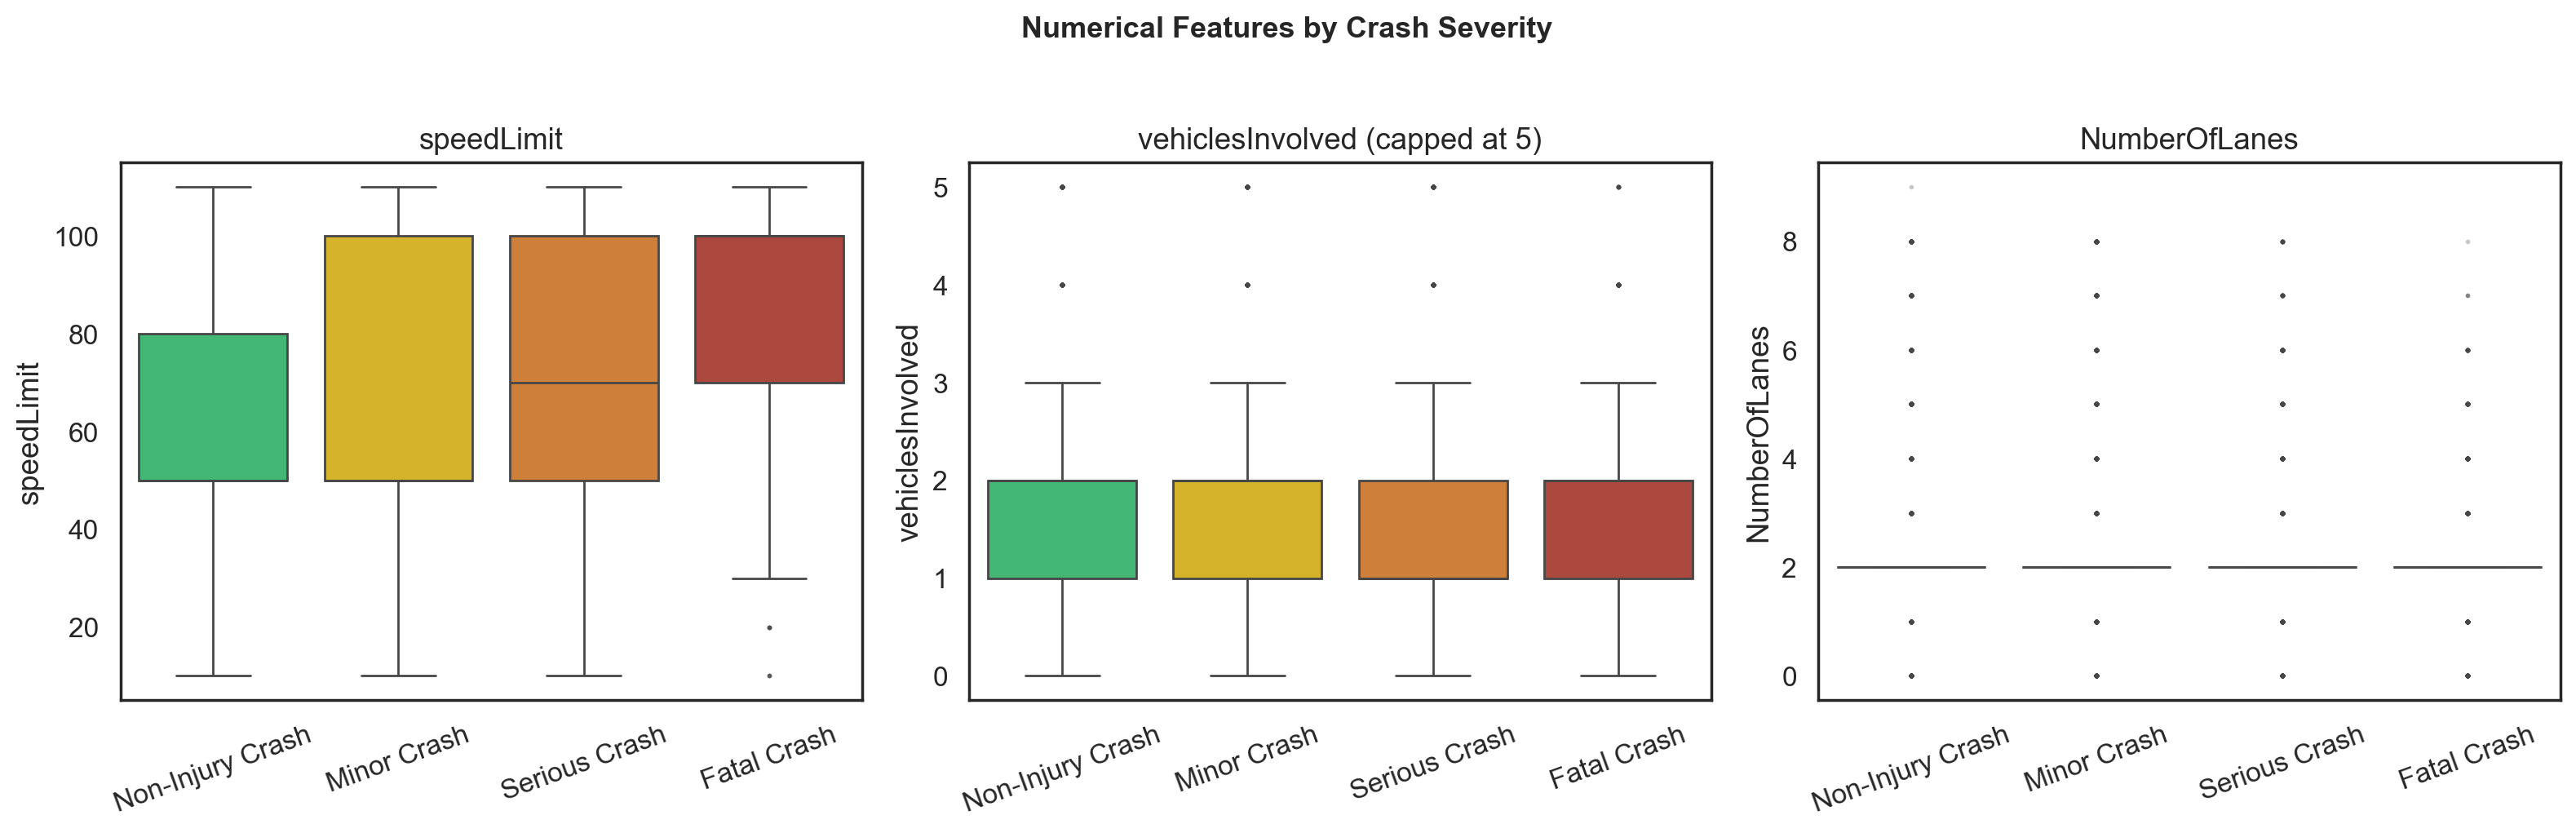

In [38]:
num_features = ['speedLimit', 'vehiclesInvolved', 'NumberOfLanes']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_features):
    plot_data = df[df['vehiclesInvolved'] <= 5] if col == 'vehiclesInvolved' else df
    sns.boxplot(
        data=plot_data, x='crashSeverity', y=col,
        order=severity_order, palette=severity_palette,
        flierprops=dict(marker='.', markersize=2, alpha=0.3),
        ax=ax
    )
    ax.set_title(col + (' (capped at 5)' if col == 'vehiclesInvolved' else ''))
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Numerical Features by Crash Severity', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The only variable that has a high variety between class in the target variable is speedLimit. We can see there is an association of Fatal Crash with higher speedLimit and non-injury crash mostly fall into lower speedLimit.

### Categorical Features vs Crash Severity

Each bar shows the proportion of each severity class within that category. Bars are sorted by descending Fatal + Serious crash rate so the highest-risk categories appear first.

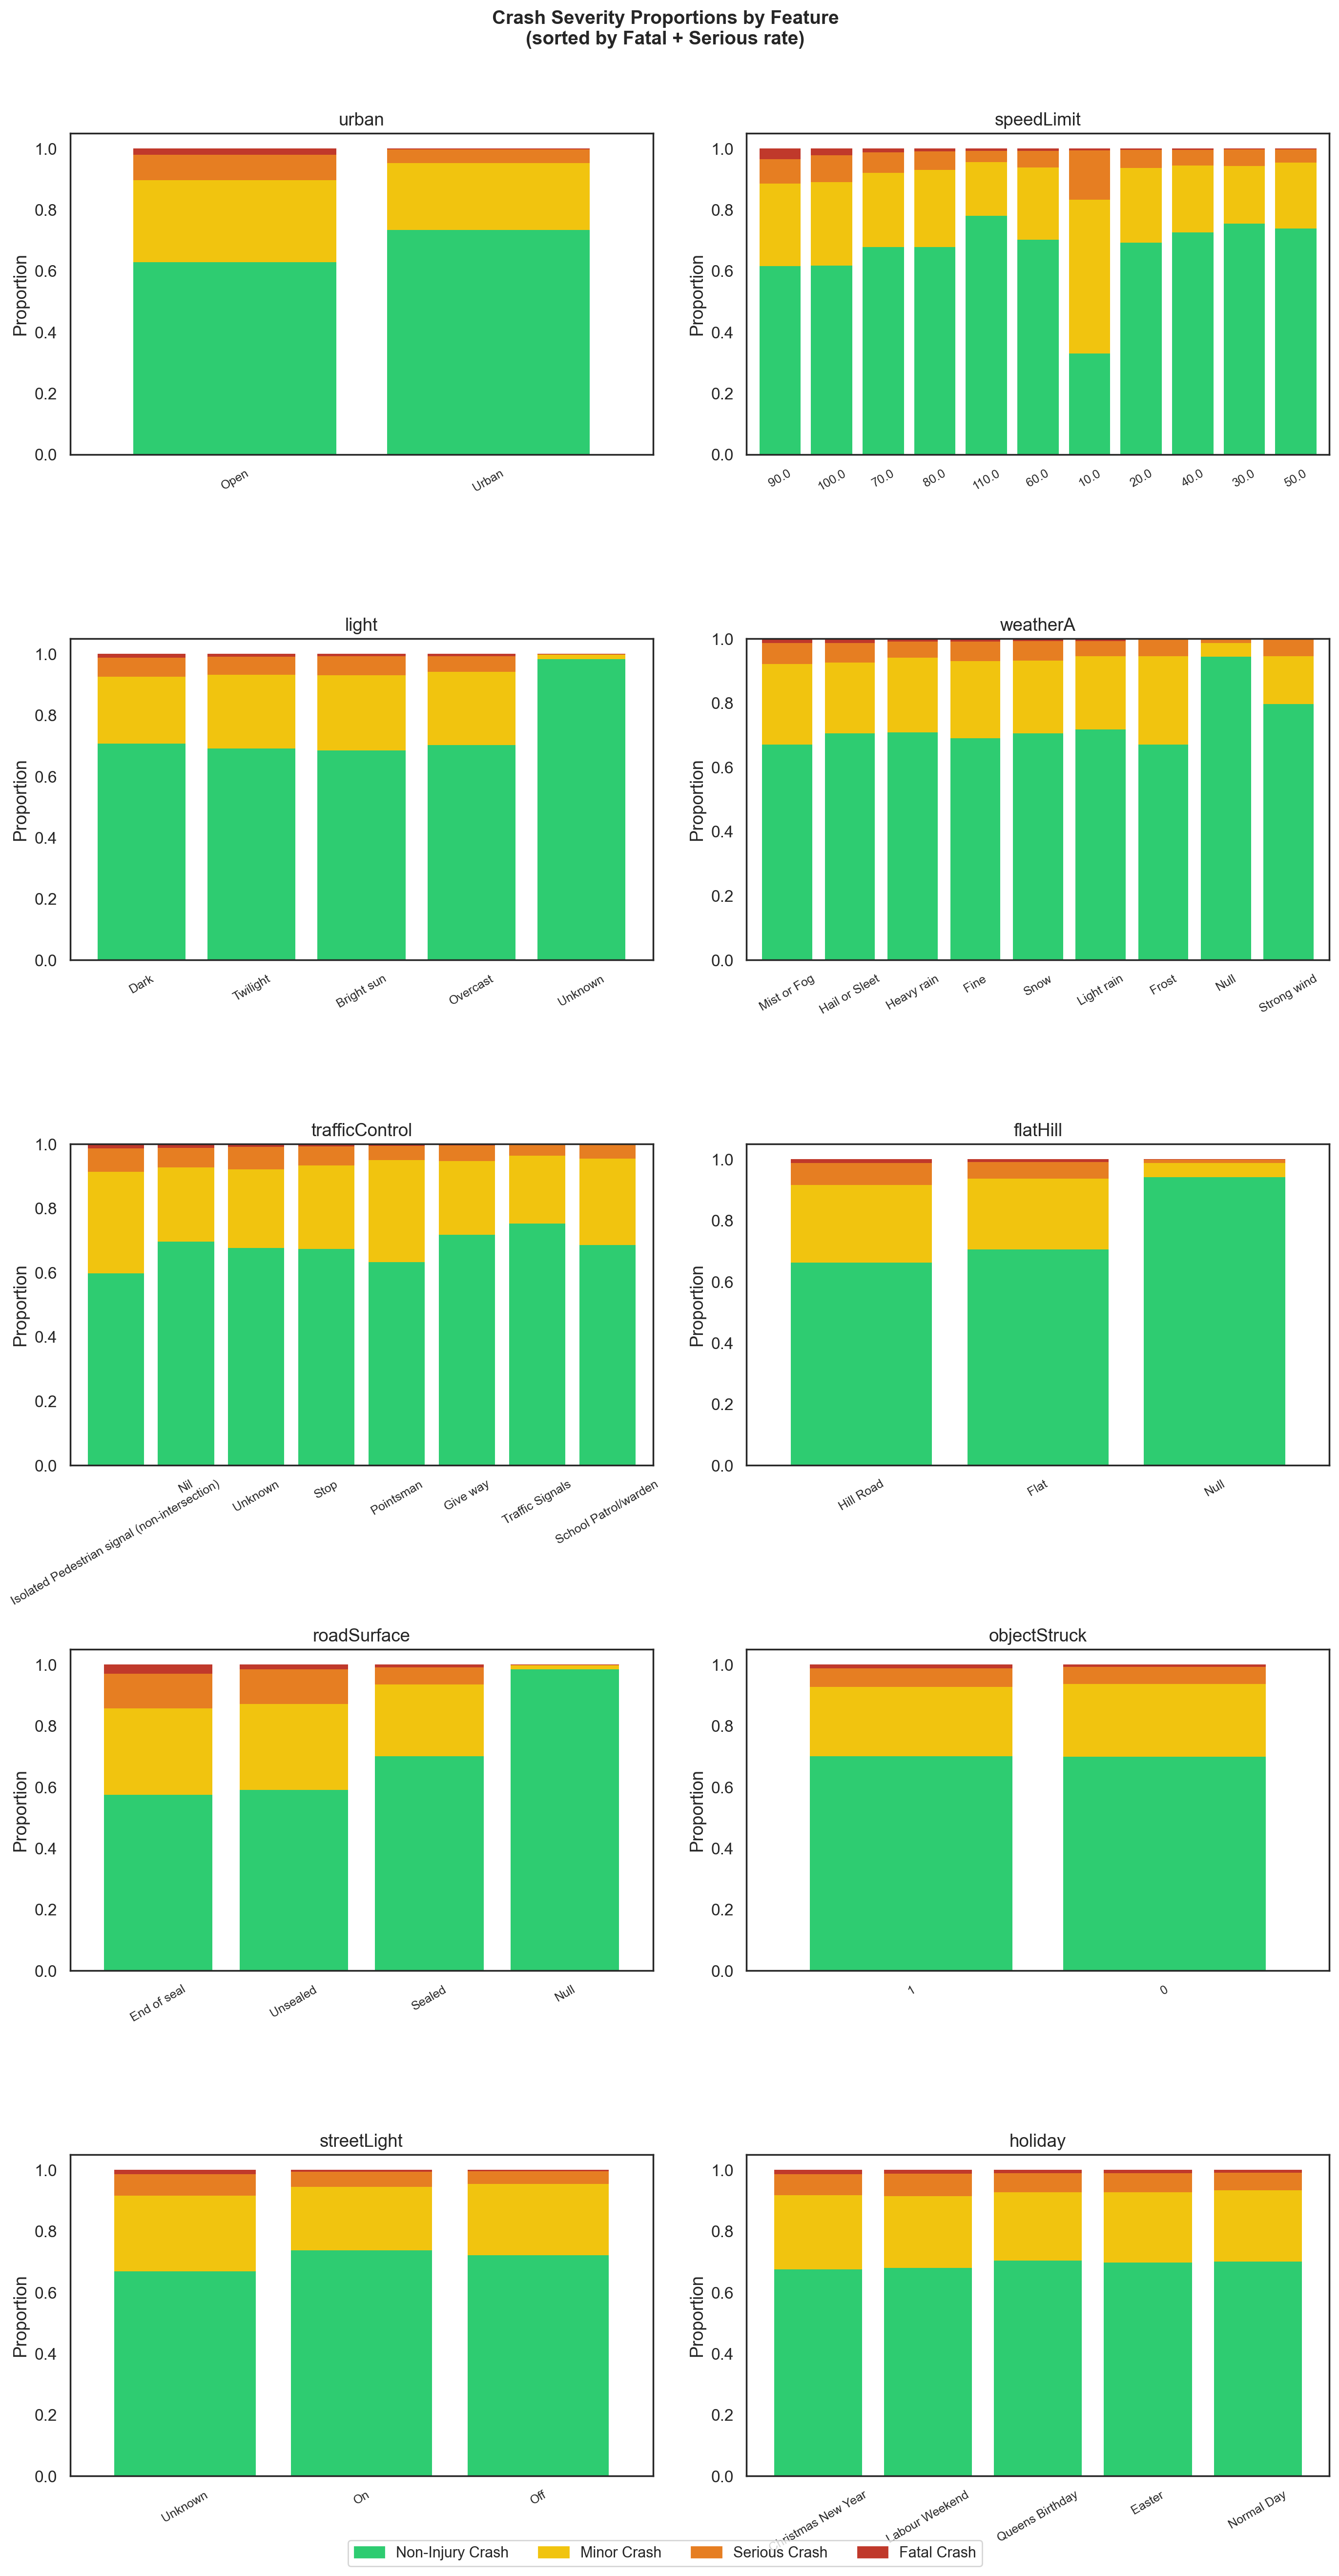

In [39]:
def severity_prop_plot(df, col, ax):
    props = (
        df.groupby(col, observed=True)['crashSeverity']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(columns=severity_order, fill_value=0)
    )
    props = props.sort_values(by=['Fatal Crash', 'Serious Crash'], ascending=False)
    props.plot(kind='bar', stacked=True, ax=ax,
               color=[severity_palette[s] for s in severity_order],
               legend=False, edgecolor='none', width=0.8)
    ax.set_xlabel('')
    ax.set_ylabel('Proportion')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30, labelsize=9)

cat_features = [
    'urban', 'speedLimit', 'light', 'weatherA',
    'trafficControl', 'flatHill', 'roadSurface', 'objectStruck',
    'streetLight', 'holiday'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 26))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    severity_prop_plot(df, col, axes[i])

handles = [plt.Rectangle((0, 0), 1, 1, color=severity_palette[s]) for s in severity_order]
fig.legend(handles, severity_order, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, 0), fontsize=11)
plt.suptitle('Crash Severity Proportions by Feature\n(sorted by Fatal + Serious rate)',
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

External factors such as weather, road surface, streetlight etc seems to have a relationship with the target - as expected - bad driving condition leads to more deadly crashes.

### Association Strength (Cramér's V)

Cramér's V measures how strongly each feature is associated with crash severity, treating all features as categorical. Values ≥ 0.1 indicate a weak association; ≥ 0.3 moderate.

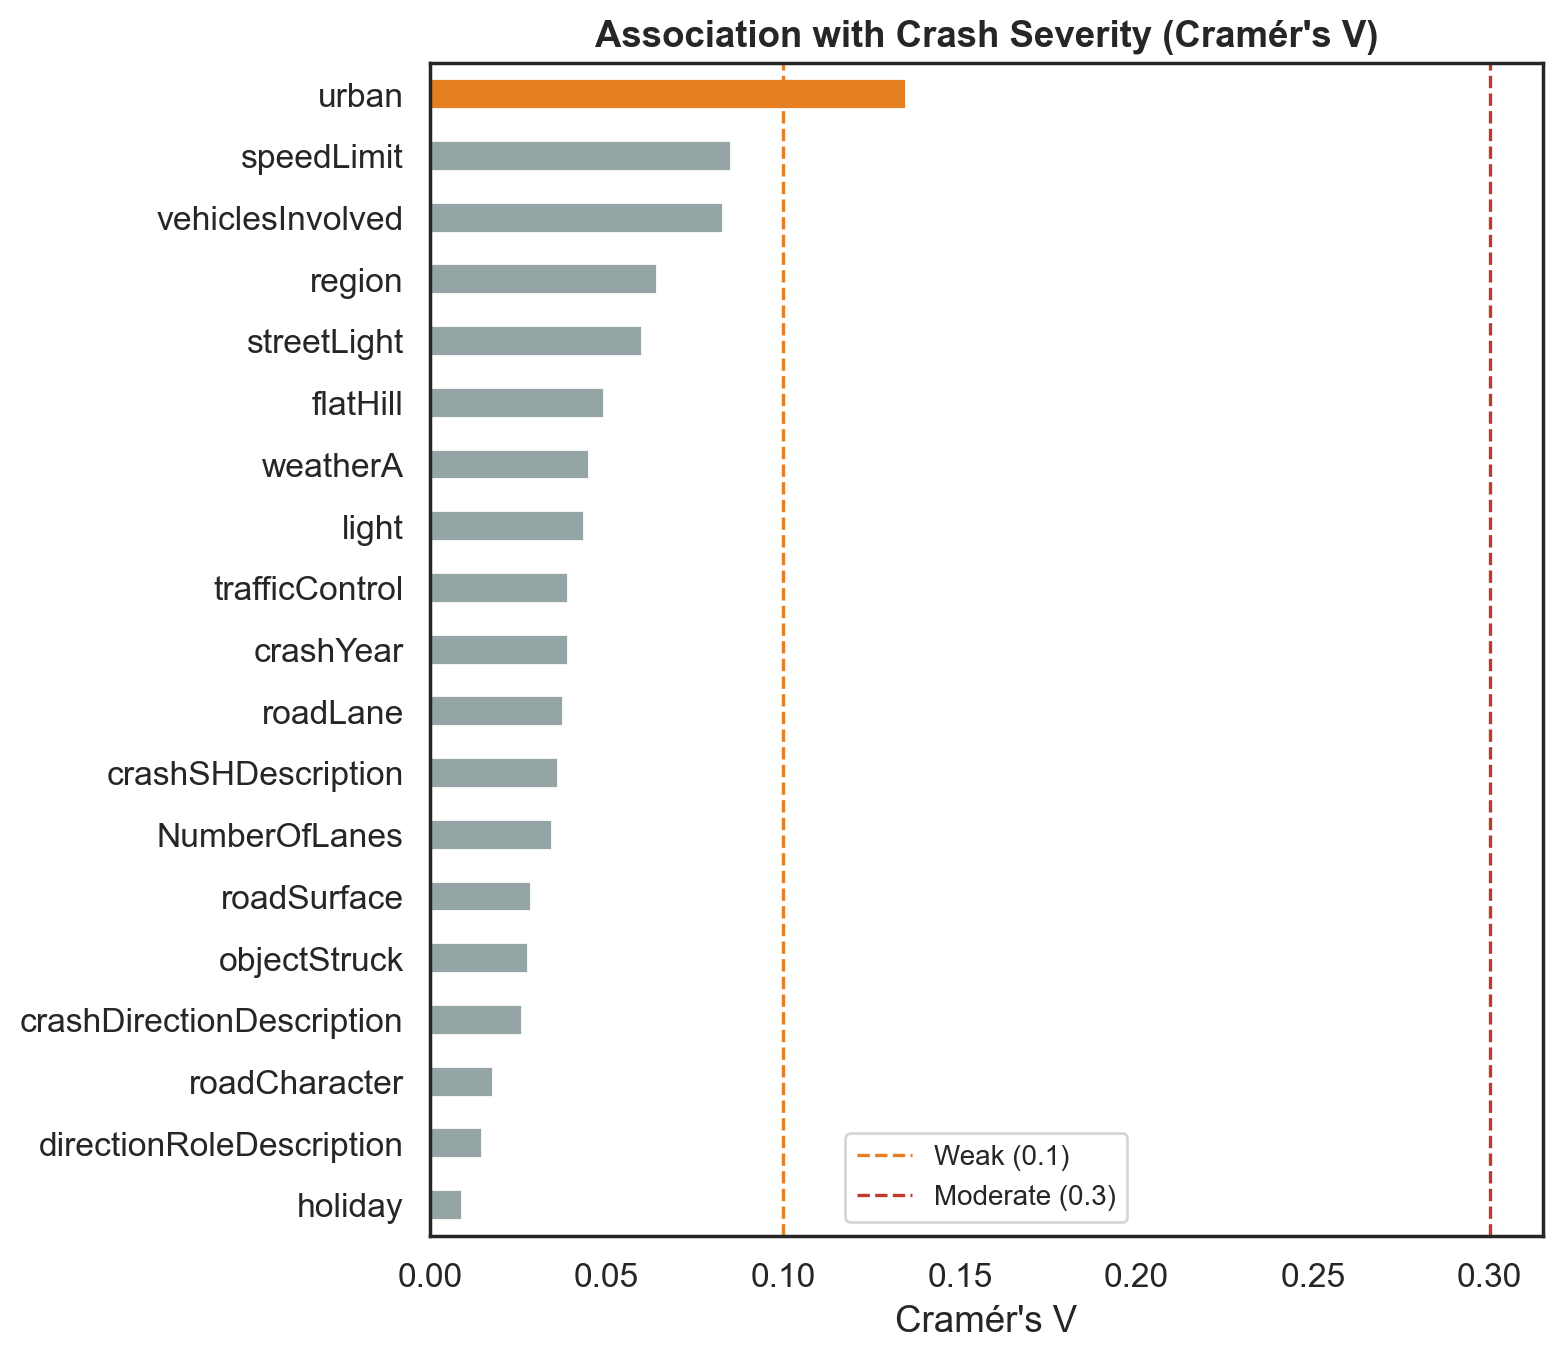

In [40]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.to_numpy().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / n / min(r - 1, k - 1))

features = [c for c in df.columns if c != 'crashSeverity']
scores = {col: cramers_v(df[col].astype(str), df['crashSeverity'].astype(str)) for col in features}

cv = pd.Series(scores).sort_values()
bar_colors = ['#c0392b' if v >= 0.3 else '#e67e22' if v >= 0.1 else '#95a5a6' for v in cv]

fig, ax = plt.subplots(figsize=(8, 7))
cv.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(0.1, color='#e67e22', linestyle='--', linewidth=1.2, label='Weak (0.1)')
ax.axvline(0.3, color='#c0392b', linestyle='--', linewidth=1.2, label='Moderate (0.3)')
ax.set_xlabel("Cramér's V")
ax.set_title("Association with Crash Severity (Cramér's V)", fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Based on Cramer's V score, only Urban has a weak association with the target variable and others do not seem to have any association with the target. This is to be expected as: 
1. Our target class is highly imbalance. 
2. Cramer's V only sees pairwise relationship, does not evaluate interaction effects. 

So we have to take class imbalance into account and are likely to be using models that capture relationships and non linear patterns.

### Severity Trend Over Years

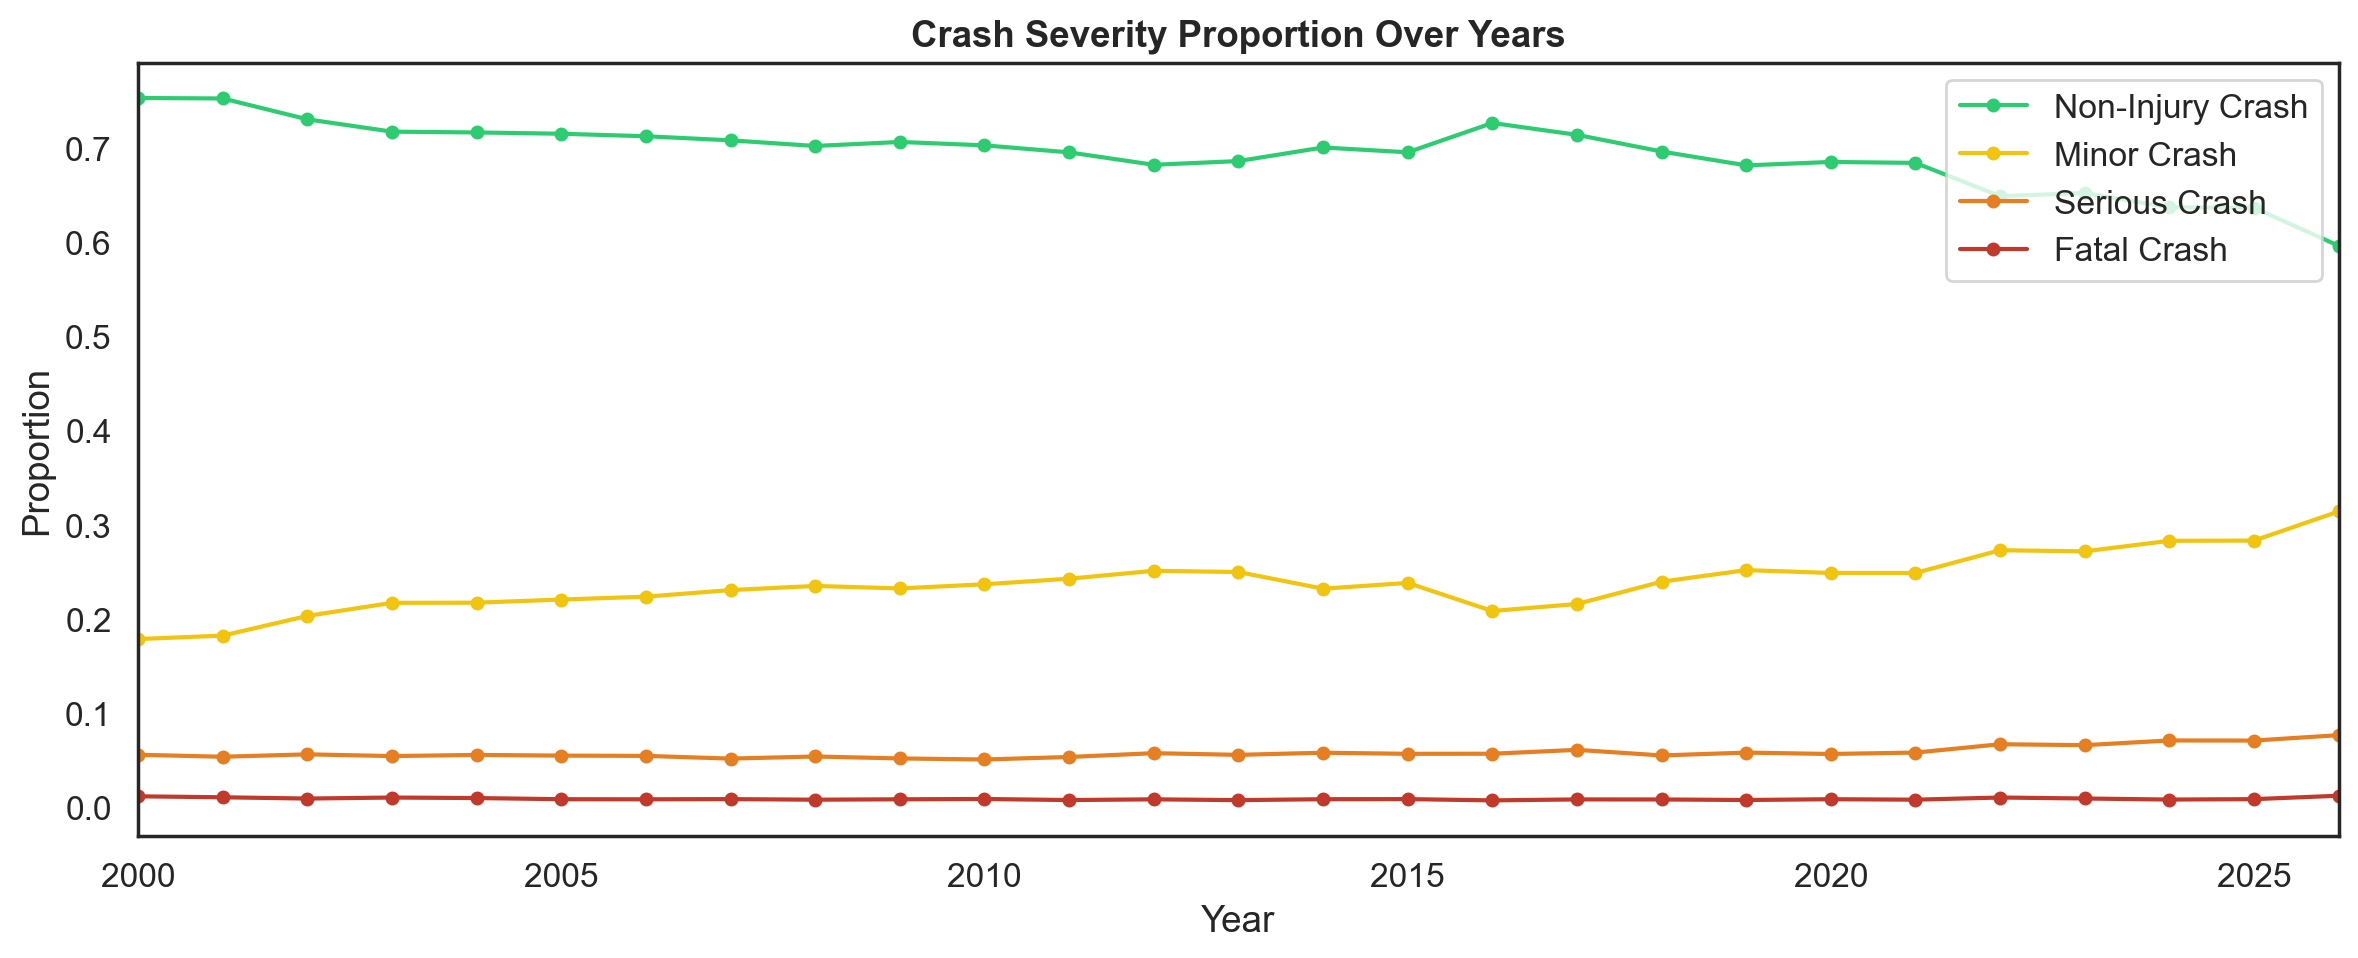

In [41]:
year_props = (
    df.groupby('crashYear')['crashSeverity']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=severity_order)
)

fig, ax = plt.subplots(figsize=(12, 5))
for sev in severity_order:
    ax.plot(year_props.index, year_props[sev], marker='o', markersize=4,
            label=sev, color=severity_palette[sev])

ax.set_title('Crash Severity Proportion Over Years', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion')
ax.legend(loc='upper right')
ax.set_xlim(year_props.index.min(), year_props.index.max())
plt.tight_layout()
plt.show()

While Non-injury crash seems to go down in the later years (after 2020), Minor crash has an upward trend in the same period. Serious Crash and Fatal Crash both remained steady.